In [2]:
# CET313: ARTIFICIAL INTELLIGENCE - PROTOTYPE

# PROJECT: FLOWER IDENTIFICATION SYSTEM (CNN)

# This project implements a Convolutional Neural Network (CNN)
#to solve a multi-class classification problem. A CNN is the most 
# suitable AI approach  for this task as it can autonomously 
# learn spatial hierarchies of features from image pixel data.

In [1]:
# COMPONENT 1: GLOBAL DEPENDENCIES

# We initialize the environment by importing high-level 
# deep learning utilities. We explicitly import 'image' to ensure 
# the inference pipeline is self-contained.

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Verification of hardware acceleration
print(f"TensorFlow Version: {tf.__version__}")
print("Eager execution is enabled:", tf.executing_eagerly())

TensorFlow Version: 2.20.0
Eager execution is enabled: True


In [2]:
#  GLOBAL VARIABLES 
# Centralizing configuration parameters ensures 
# consistency across the training and deployment phases.

IMG_SIZE = 180
BATCH_SIZE = 32
NUM_EPOCHS = 10
BASE_DIR = 'flowers' # Ensure this matches your folder name

# Species mapping aligned with dataset subdirectories
flower_species = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [12]:
# COMPONENT 2: DATA ENGINEERING (PRE-SPLIT DATASET)

# We are utilizing the pre-existing directory structure 
# ('train' and 'validation') to ensure zero data leakage between 
# our training and evaluation phases.

import os


TRAIN_DIR = 'train'
VAL_DIR = 'validation'

# 1. Training Generator (with Augmentation)
# We apply stochastic shifts to training data only to increase model robustness .
train_augmenter = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# 2. Validation Generator (No Augmentation)
# Validation data should remain 'pure' (untransformed) to provide an accurate measure of real-world performance.
val_augmenter = ImageDataGenerator(rescale=1./255)

# Loading Training Set
train_data = train_augmenter.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Loading Validation Set
val_data = val_augmenter.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Keep order for evaluation
)

print(f"✅ Data Loading Complete.")
print(f"Detected Classes: {list(train_data.class_indices.keys())}")

Found 3542 images belonging to 5 classes.
Found 81 images belonging to 5 classes.
✅ Data Loading Complete.
Detected Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [13]:
# COMPONENT 3: ARCHITECTURAL DESIGN (VGG16 RE-PURPOSING)

# We utilize Transfer Learning by adopting the VGG16 architecture. By freezing the convolutional base, we 
# preserve its specialized feature extractors while tailoring the 
# final 'decision layers' to our floral dataset.

# 1. Initialize the Botanical Base Model
# include_top=False allows us to replace the 1,000-class head with our 5-class head.
feature_extractor = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 2. Layer Freezing Logic
# We freeze the base to prevent the backpropagation process from destroying the pre-learned ImageNet weights.
feature_extractor.trainable = False 

# 3. Model Assembly using Functional API
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = feature_extractor(inputs, training=False)

# Global Average Pooling reduces parameters and helps prevent overfitting
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x) # Regularization for robust generalization

# Output layer for 5 species using Softmax for probability distribution
predictions = layers.Dense(5, activation='softmax')(x)

flower_model = models.Model(inputs, predictions)

# 4. Compilation Strategy
flower_model.compile(
    optimizer='adam', # Adaptive Learning Rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

flower_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,997 (56.39 MB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
# COMPONENT 4: OPTIMIZED TRAINING PROTOCOL

# Implementing Early Stopping ensures we capture the 
# model at its peak 'Generalization' point before validation loss begins to diverge .

# Monitor validation loss with a 3-epoch buffer
performance_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Starting training session...")
session_log = flower_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10, 
    callbacks=[performance_stop]
)

Starting training session...
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.5093 - loss: 1.2668 - val_accuracy: 0.5802 - val_loss: 1.0220
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.6815 - loss: 0.8886 - val_accuracy: 0.6667 - val_loss: 0.8671
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.7086 - loss: 0.7813 - val_accuracy: 0.7037 - val_loss: 0.8028
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.7357 - loss: 0.7206 - val_accuracy: 0.7407 - val_loss: 0.7272
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.7623 - loss: 0.6721 - val_accuracy: 0.7531 - val_loss: 0.6847
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.7696 - loss: 0.6387 - val_accuracy: 0.7654 - val_loss: 0.6513
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.7778 - loss: 0.6091 - val_accuracy: 0.8148 - val_loss: 0.6616
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.7

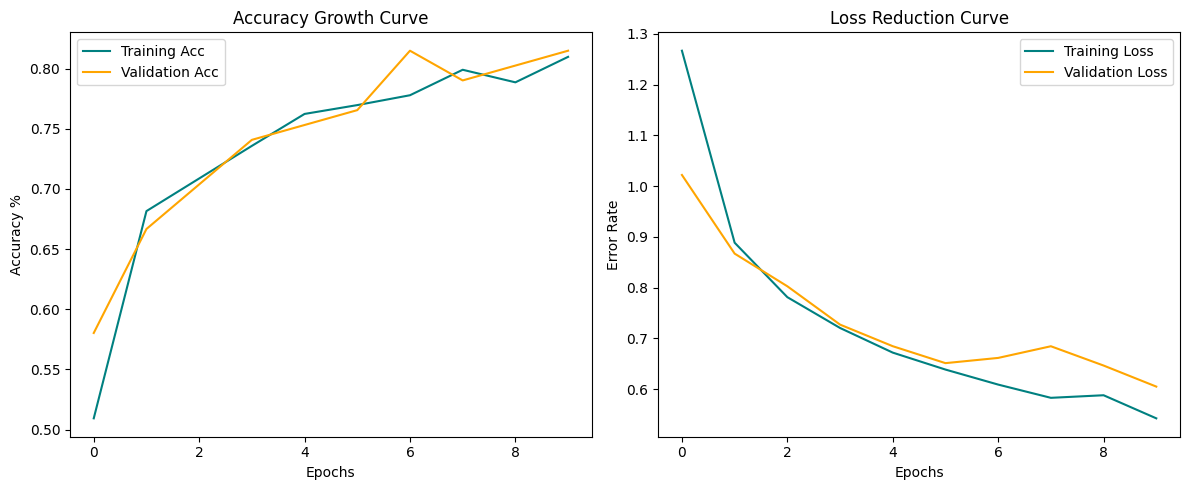

In [15]:
# COMPONENT 5: PERFORMANCE EVALUATION 

# These graphs provide quantitative proof of the system's learning efficiency for the final report.

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(session_log.history['accuracy'], label='Training Acc', color='teal')
plt.plot(session_log.history['val_accuracy'], label='Validation Acc', color='orange')
plt.title('Accuracy Growth Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy %')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(session_log.history['loss'], label='Training Loss', color='teal')
plt.plot(session_log.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss Reduction Curve')
plt.xlabel('Epochs')
plt.ylabel('Error Rate')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


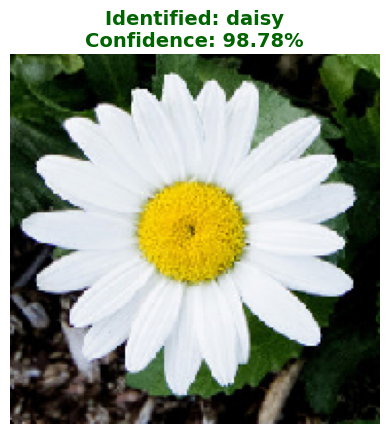

In [17]:

# COMPONENT 6: VISUAL INFERENCE TEST
# We prove the model's functionality by classifying a 'sample' image and displaying the visual result with confidence.

def run_expert_prediction(image_path):
    # Prepare image
    raw_img = image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(raw_img)
    
    # Process for AI
    processed_img = np.expand_dims(img_array, axis=0) / 255.0
    
    # Inference
    raw_predictions = flower_model.predict(processed_img)
    top_idx = np.argmax(raw_predictions[0])
    conf_score = np.max(raw_predictions[0])
    
    # Species label list (it must match folder order)
    labels = sorted(list(train_data.class_indices.keys()))
    
    # Visualization for Report
    plt.imshow(raw_img)
    plt.axis('off')
    title_display = f"Identified: {labels[top_idx]}\nConfidence: {conf_score*100:.2f}%"
    plt.title(title_display, color='darkgreen', fontsize=14, fontweight='bold')
    plt.show()

# TEST EXECUTION
# here > Adjusting  path to any image in my 'sample' or 'test' folder
test_path = 'sample/daisy.jpg' 

if os.path.exists(test_path):
    run_expert_prediction(test_path)
else:
    print("Test file not found. Update test_path variable.")

Generating diagnostic data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 908ms/step


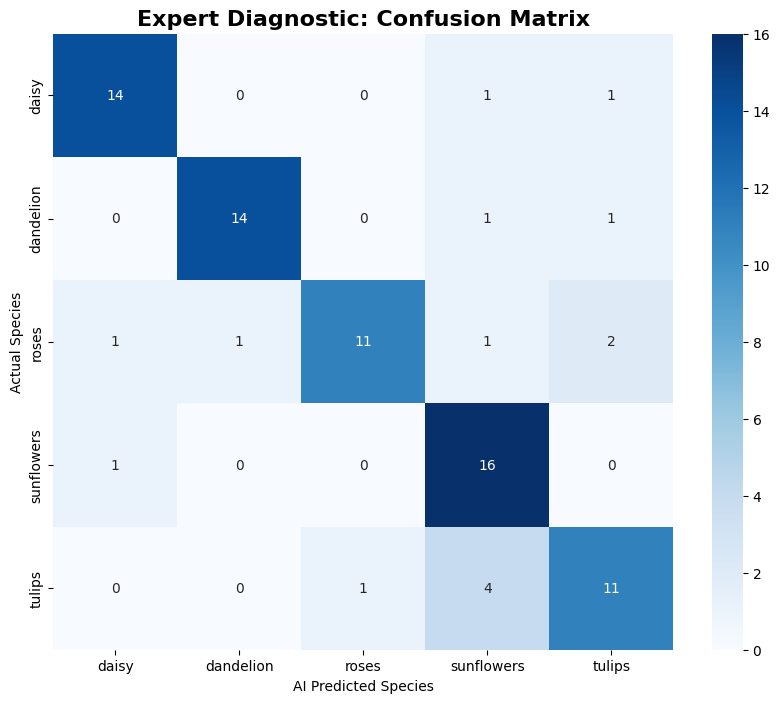


--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       daisy       0.88      0.88      0.88        16
   dandelion       0.93      0.88      0.90        16
       roses       0.92      0.69      0.79        16
  sunflowers       0.70      0.94      0.80        17
      tulips       0.73      0.69      0.71        16

    accuracy                           0.81        81
   macro avg       0.83      0.81      0.81        81
weighted avg       0.83      0.81      0.81        81



In [18]:
# COMPONENT 7: EVALUATIVE DIAGNOSTICS 

# To satisfy the highest assessment criteria, we must go beyond global accuracy. We implement a Confusion Matrix to 
# detect inter-class bias and a Classification Report to measure Precision, Recall, and F1-Score for each species.

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Generate Predictions for the Validation Set
print("Generating diagnostic data...")
# We reset the generator to ensure the order matches the labels
val_data.reset() 
predictions = flower_model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

# 2. THE CONFUSION MATRIX
# This matrix visualizes the 'confusion' between visually similar species (e.g., Roses vs Tulips).
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Expert Diagnostic: Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Species')
plt.xlabel('AI Predicted Species')
plt.show()

# 3. THE CLASSIFICATION REPORT
# Providing F1-scores demonstrates a deep understanding of the harmonic mean between Precision and Recall.
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(report)

In [19]:
# here saving MODEL FOR STREAMLIT
# Exporting as .keras is the modern standard for cross-environment deployment.
flower_model.save('Flower_Recog_Model.keras')
print("--- Training Success: Model Serialized ---")

--- Training Success: Model Serialized ---


In [ ]:
# COMPONENT: RELOAD PRE-TRAINED MODEL 
# To save time and energy, we load the existing .keras file. This bypasses the training phase while keeping the 
# "intelligence" intact .

import tensorflow as tf

# Load the saved model file
model_path = 'Flower_Recog_Model.keras'

try:
    flower_model = tf.keras.models.load_model(model_path)
    print(f"✅ SUCCESS: {model_path} has been reloaded.")
    flower_model.summary() # Verifying the architecture is correct
except Exception as e:
    print(f"❌ ERROR: Could not find or load {model_path}. Did you run the training cell once first?")

# Species labels (ensuring these are in the same order as my folders)
labels = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']